# Building the dataframes

## Working with voting sessions

In [2]:
import requests
import urllib.parse
import time
from typing import Dict, Any
class DanishParliamentAPI:
    def __init__(self, timeout: int = 30, retry_attempts: int = 3):
        """
        Initialize the API client.

        Args:
            timeout: Request timeout in seconds
            retry_attempts: Number of retry attempts for failed requests
        """
        self.base_url = "https://oda.ft.dk/api/"
        self.timeout = timeout
        self.retry_attempts = retry_attempts
        self.last_request_time = 0
        self.min_request_interval = 0.1  # Minimum 100ms between requests

    def _rate_limit(self) -> None:
        """Enforce rate limiting between requests."""
        elapsed = time.time() - self.last_request_time
        if elapsed < self.min_request_interval:
            time.sleep(self.min_request_interval - elapsed)
        self.last_request_time = time.time()

    def _make_request(self, url: str) -> Dict[str, Any]:
        """
        Make HTTP request with retry logic and error handling.

        Args:
            url: Complete URL to request

        Returns:
            Parsed JSON response

        Raises:
            APIError: For various API errors
            NetworkError: For network-related errors
        """
        self._rate_limit()

        for attempt in range(self.retry_attempts):
            try:
                response = requests.get(url, timeout=self.timeout)

                # Handle different HTTP status codes
                if response.status_code == 200:
                    return response.json()
                elif response.status_code == 400:
                    raise APIError(
                        f"Invalid query parameters. Check $expand and $filter syntax. "
                        f"URL: {url}"
                    )
                elif response.status_code == 404:
                    if 'api/' in url and url.count('/') == 4:  # Entity not found
                        raise EntityNotFoundError(f"Entity not found: {url}")
                    else:  # Invalid ID
                        raise RecordNotFoundError(f"Record not found: {url}")
                elif response.status_code == 501:
                    raise UnsupportedOperationError(
                        "Write operations are not supported by this API"
                    )
                else:
                    response.raise_for_status()

            except requests.exceptions.Timeout:
                if attempt < self.retry_attempts - 1:
                    wait_time = (2 ** attempt) * 1  # Exponential backoff
                    time.sleep(wait_time)
                    continue
                raise NetworkError(f"Request timed out after {self.timeout} seconds")

            except requests.exceptions.ConnectionError:
                if attempt < self.retry_attempts - 1:
                    wait_time = (2 ** attempt) * 1
                    time.sleep(wait_time)
                    continue
                raise NetworkError("Connection error - check your internet connection")

            except requests.exceptions.RequestException as e:
                raise NetworkError(f"Request failed: {str(e)}")

    def _build_url(self, entity: str, **params) -> str:
        """
        Build properly encoded URL with OData parameters.

        Args:
            entity: Entity name (e.g., 'Sag', 'Aktør')
            **params: OData parameters

        Returns:
            Complete URL with encoded parameters
        """
        # Start with base URL and entity
        url = f"{self.base_url}{entity}"

        if not params:
            return url

        # Build query parameters with proper encoding
        query_parts = []
        for key, value in params.items():
            if value is not None:
                # Ensure $ parameters are properly encoded
                if key.startswith('$'):
                    encoded_key = urllib.parse.quote(key, safe='$')
                else:
                    encoded_key = key

                encoded_value = urllib.parse.quote(str(value), safe="(),'/%")
                query_parts.append(f"{encoded_key}={encoded_value}")

        return f"{url}?{'&'.join(query_parts)}"



# Custom Exception Classes
class APIError(Exception):
    """Base exception for API errors."""
    pass

class NetworkError(APIError):
    """Network-related errors."""
    pass

class EntityNotFoundError(APIError):
    """Entity does not exist."""
    pass

class RecordNotFoundError(APIError):
    """Specific record does not exist."""
    pass

class UnsupportedOperationError(APIError):
    """Operation not supported by API."""
    pass

Start by fetching all the voting sessions. Each row represents one voting procedure in the Folketing, in the API the 'Afstemning'-tag only gets very limited info, but we expand the Møde and Sagstrin columns to get info about the session the vote took place in as well as the case-phase which tells us about the proposal being voted for.

In [12]:
import pandas as pd
api = DanishParliamentAPI()

all_voting_session_data = []
skip = 0
batch_size = 100

while True:
    votings_response = api._make_request(api._build_url('Afstemning', **{
        '$top': batch_size, 
        '$expand': 'Møde,Sagstrin',
        '$skip': skip
    }))
    
    voting_session_data = votings_response.get('value', [])
    if not voting_session_data:
        break
    
    all_voting_session_data.extend(voting_session_data)
    skip += batch_size
    
    if skip % 500 == 0:
        print(f"  Fetched {skip} voting sessions...")

print(f"Total votings sessions fetched: {len(all_voting_session_data)}")

  Fetched 500 voting sessions...
  Fetched 1000 voting sessions...
  Fetched 1500 voting sessions...
  Fetched 2000 voting sessions...
  Fetched 2500 voting sessions...
  Fetched 3000 voting sessions...
  Fetched 3500 voting sessions...
  Fetched 4000 voting sessions...
  Fetched 4500 voting sessions...
  Fetched 5000 voting sessions...
  Fetched 5500 voting sessions...
  Fetched 6000 voting sessions...
  Fetched 6500 voting sessions...
  Fetched 7000 voting sessions...
  Fetched 7500 voting sessions...
  Fetched 8000 voting sessions...
  Fetched 8500 voting sessions...
  Fetched 9000 voting sessions...
  Fetched 9500 voting sessions...
  Fetched 10000 voting sessions...
Total votings sessions fetched: 10306


The Field from Møde and Sagstrin are nested by default, so we flatten those columns being careful to label the columns which are named similarly across the three different databases.

In [13]:
def flatten_voting_session(v: Dict[str, Any]) -> Dict[str, Any]:
    """Flatten a single voting session record with all nested data."""
    flat = {
        # Afstemning fields
        'afstemning_id': v.get('id'),
        'afstemning_nummer': v.get('nummer'),
        'afstemning_konklusion': v.get('konklusion'),
        'afstemning_vedtaget': v.get('vedtaget'),
        'afstemning_kommentar': v.get('kommentar'),
        'afstemning_dato': v.get('dato'),
        'afstemning_opdateringsdato': v.get('opdateringsdato'),
        'afstemning_typeid': v.get('typeid'),
        
        # From Møde (nested)
        'møde_id': None,
        'møde_dato': None,
        'møde_titel': None,
        'møde_nummer': None,
        'møde_periodeid': None,
        
        # From Sagstrin (nested)
        'sagstrin_id': None,
        'sagstrin_titel': None,
        'sagstrin_typeid': None,
        'sag_id': None,
    }
    
    # Extract Møde fields
    møde = v.get('Møde')
    if isinstance(møde, dict):
        flat['møde_id'] = møde.get('id')
        flat['møde_dato'] = møde.get('dato')
        flat['møde_titel'] = møde.get('titel')
        flat['møde_nummer'] = møde.get('nummer')
        flat['møde_periodeid'] = møde.get('periodeid')
    
    # Extract Sagstrin fields
    sagstrin = v.get('Sagstrin')
    if isinstance(sagstrin, dict):
        flat['sagstrin_id'] = sagstrin.get('id')
        flat['sagstrin_titel'] = sagstrin.get('titel')
        flat['sagstrin_typeid'] = sagstrin.get('typeid')
        flat['sag_id'] = sagstrin.get('sagid')
    
    return flat

# Flatten all voting sessions
flattened_voting_sessions = [flatten_voting_session(v) for v in all_voting_session_data]

In [15]:
import pandas as pd
voting_sessions_df = pd.DataFrame(flattened_voting_sessions)
voting_sessions_df

,afstemning_id,afstemning_nummer,afstemning_konklusion,afstemning_vedtaget,afstemning_kommentar,afstemning_dato,afstemning_opdateringsdato,afstemning_typeid,møde_id,møde_dato,møde_titel,møde_nummer,møde_periodeid,sagstrin_id,sagstrin_titel,sagstrin_typeid,sag_id
0,1,411,"Vedtaget\n\n108 stemmer for forslaget (V, S, D...",True,None,None,2014-09-09T09:05:59.653,2,17,2014-09-09T09:00:00,Møde i salen,104,32,NaN,None,NaN,NaN
1,2,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,None,None,2014-09-09T09:25:05.717,1,18,2014-09-09T09:15:00,Møde i salen,105,32,4849.0,3. behandling,17.0,1449.0
2,3,1,"Vedtaget\n\n59 stemmer for forslaget (S, RV, S...",True,,None,2018-01-24T16:46:33.99,3,41,2012-10-04T10:00:00,Møde i salen,3,31,17351.0,Behandling,10.0,5604.0
3,4,7,"Vedtaget\n\n72 stemmer for forslaget (S, DF, R...",True,,None,2018-01-25T10:25:25.64,1,156,2012-11-06T00:00:00,Møde i salen,15,31,18370.0,3. behandling,17.0,5904.0
4,5,412,"Vedtaget\n\n98 stemmer for forslaget (V, S, DF...",True,,None,2017-08-10T12:57:52.27,1,18,2014-09-09T09:15:00,Møde i salen,105,32,4849.0,3. behandling,17.0,1449.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10301,10378,533,"Vedtaget\nFor stemte 93 (S, V, DD, SF, LA, M, ...",True,Grundet en teknisk fejl kunne der ikke stemmes...,None,2025-09-30T14:56:15.043,1,15399,2025-09-30T13:00:00,Møde i salen,112,163,267397.0,3. behandling,17.0,102719.0
10302,10379,2,"Vedtaget\nFor stemte 59 (S, V, M, JF, Jeppe Sø...",True,,None,2025-10-10T11:45:43.137,3,15443,2025-10-09T08:00:00,Møde i salen,3,165,268868.0,Behandling,10.0,103247.0
10303,10380,3,"Forslaget er vedtaget\nFor stemte 56 (S, V og ...",True,,None,2025-10-24T09:45:23.93,3,15446,2025-10-23T10:00:00,Møde i salen,6,165,269214.0,Behandling,10.0,103374.0
10304,10381,5,"Forslaget er vedtaget.\nFor stemte 96 (S, V, D...",True,Ved en fejl stemte Alex Ahrendtsen (DF) for fo...,None,2025-11-24T11:14:43.697,1,15454,2025-11-20T10:15:00,Møde i salen,15,165,268341.0,Eventuelt: 3. behandling,17.0,103133.0


Every sagstrin (case-phase) is part of a sag (case) which contains further info including the title and resume of the case, we find all the sag_ids that are referenced in our df and merge that info back into our dataframe.

In [16]:
unique_sagids = voting_sessions_df['sag_id'].dropna().unique()
print(f"\nUnique cases to fetch: {len(unique_sagids)}")

all_sag_data = []
for i, sagid in enumerate(unique_sagids):
    if i % 100 == 0:
        print(f"  Fetched {i}/{len(unique_sagids)} cases...")
    
    try:
        sag_response = api._make_request(api._build_url('Sag', **{
            '$filter': f'id eq {int(sagid)}'
        }))
        
        sag_data = sag_response.get('value', [])
        if sag_data:
            all_sag_data.extend(sag_data)
    except Exception as e:
        print(f"  Error fetching Sag {sagid}: {e}")
        continue




Unique cases to fetch: 6871
  Fetched 0/6871 cases...
  Fetched 100/6871 cases...
  Fetched 200/6871 cases...
  Fetched 300/6871 cases...
  Fetched 400/6871 cases...
  Fetched 500/6871 cases...
  Fetched 600/6871 cases...
  Fetched 700/6871 cases...
  Fetched 800/6871 cases...
  Fetched 900/6871 cases...
  Fetched 1000/6871 cases...
  Fetched 1100/6871 cases...
  Fetched 1200/6871 cases...
  Fetched 1300/6871 cases...
  Fetched 1400/6871 cases...
  Fetched 1500/6871 cases...
  Fetched 1600/6871 cases...
  Fetched 1700/6871 cases...
  Fetched 1800/6871 cases...
  Fetched 1900/6871 cases...
  Fetched 2000/6871 cases...
  Fetched 2100/6871 cases...
  Fetched 2200/6871 cases...
  Fetched 2300/6871 cases...
  Fetched 2400/6871 cases...
  Fetched 2500/6871 cases...
  Fetched 2600/6871 cases...
  Fetched 2700/6871 cases...
  Fetched 2800/6871 cases...
  Fetched 2900/6871 cases...
  Fetched 3000/6871 cases...
  Fetched 3100/6871 cases...
  Fetched 3200/6871 cases...
  Fetched 3300/6871 cases.

In [17]:
def flatten_sag(s: Dict[str, Any]) -> Dict[str, Any]:
    """Flatten a single Sag record."""
    return {
        'sag_id': s.get('id'),
        'sag_titel': s.get('titel'),
        'sag_titelkort': s.get('titelkort'),
        'sag_resume': s.get('resume'),
        'sag_nummer': s.get('nummer'),
        'sag_nummerprefix': s.get('nummerprefix'),
        'sag_opdateringsdato': s.get('opdateringsdato'),
        'sag_typeid': s.get('typeid'),
        'sag_periodeid': s.get('periodeid'),
        'sag_statusid': s.get('statusid'),
    }

flattened_sag = [flatten_sag(s) for s in all_sag_data]
sag_df = pd.DataFrame(flattened_sag)

In [18]:
sag_df.columns

Index(['sag_id', 'sag_titel', 'sag_titelkort', 'sag_resume', 'sag_nummer',
       'sag_nummerprefix', 'sag_opdateringsdato', 'sag_typeid',
       'sag_periodeid', 'sag_statusid'],
      dtype='object')

In [19]:
if sag_df['sag_id'].duplicated().any():
    print(f"WARNING: {sag_df['sag_id'].duplicated().sum()} duplicate sag_ids found!")
    sag_df = sag_df.drop_duplicates(subset='sag_id', keep='first')

print(f"Sag dataframe shape: {sag_df.shape}")
enriched_voting_sessions = voting_sessions_df.merge(
    sag_df,
    on='sag_id',
    how='left'
)

print(f"\nFinal enriched shape: {enriched_voting_sessions.shape}")
print(f"Final columns: {enriched_voting_sessions.columns.tolist()}")

Sag dataframe shape: (6871, 10)

Final enriched shape: (10306, 26)
Final columns: ['afstemning_id', 'afstemning_nummer', 'afstemning_konklusion', 'afstemning_vedtaget', 'afstemning_kommentar', 'afstemning_dato', 'afstemning_opdateringsdato', 'afstemning_typeid', 'møde_id', 'møde_dato', 'møde_titel', 'møde_nummer', 'møde_periodeid', 'sagstrin_id', 'sagstrin_titel', 'sagstrin_typeid', 'sag_id', 'sag_titel', 'sag_titelkort', 'sag_resume', 'sag_nummer', 'sag_nummerprefix', 'sag_opdateringsdato', 'sag_typeid', 'sag_periodeid', 'sag_statusid']


In order to categorize the votes according to the parliamentary periods we need to massage the dates a little and compare them against a table of the periods.

In [20]:
from folketingsperioder import periods_df
enriched_voting_sessions['møde_dato'] = pd.to_datetime(enriched_voting_sessions['møde_dato'])

# Create a mapping of Danish months to English
danish_months = {
    'januar': 'January', 'februar': 'February', 'marts': 'March',
    'april': 'April', 'maj': 'May', 'juni': 'June',
    'juli': 'July', 'august': 'August', 'september': 'September',
    'oktober': 'October', 'november': 'November', 'december': 'December'
}

def parse_date_range(date_range):
    dates = date_range.split(' – ')
    return dates[0].strip(), dates[1].strip()

def convert_danish_to_english(date_str):
    """Convert Danish month names to English."""
    for danish, english in danish_months.items():
        date_str = date_str.replace(danish, english)
    return date_str

# Create a mapping of periods with their date ranges
periods_df['start_date'] = periods_df['Date Range'].apply(lambda x: parse_date_range(x)[0])
periods_df['end_date'] = periods_df['Date Range'].apply(lambda x: parse_date_range(x)[1])

# Convert to datetime
periods_df['start_date'] = periods_df['start_date'].apply(
    lambda x: pd.to_datetime(convert_danish_to_english(x), format='%d. %B %Y', errors='coerce')
)
periods_df['end_date'] = periods_df['end_date'].apply(
    lambda x: pd.Timestamp.now() if x == 'nu' else pd.to_datetime(convert_danish_to_english(x), format='%d. %B %Y', errors='coerce')
)

# Function to find the period for a given date
def find_period(vote_date):
    for _, period in periods_df.iterrows():
        if period['start_date'] <= vote_date <= period['end_date']:
            return period['Period']
    return None

# Add period column
enriched_voting_sessions['Period'] = enriched_voting_sessions['møde_dato'].apply(find_period)


In [21]:
enriched_voting_sessions.columns

Index(['afstemning_id', 'afstemning_nummer', 'afstemning_konklusion',
       'afstemning_vedtaget', 'afstemning_kommentar', 'afstemning_dato',
       'afstemning_opdateringsdato', 'afstemning_typeid', 'møde_id',
       'møde_dato', 'møde_titel', 'møde_nummer', 'møde_periodeid',
       'sagstrin_id', 'sagstrin_titel', 'sagstrin_typeid', 'sag_id',
       'sag_titel', 'sag_titelkort', 'sag_resume', 'sag_nummer',
       'sag_nummerprefix', 'sag_opdateringsdato', 'sag_typeid',
       'sag_periodeid', 'sag_statusid', 'Period'],
      dtype='object')

In [ ]:
# enriched_voting_sessions.to_csv('./voting-data/voting_sessions_enriched.csv', index=False)
# print("\nData saved to './voting-data/voting_sessions_enriched.csv'")


Data saved to 'folketinget_votings_enrichedv2.csv'


### Assigning topics

In order to talk talk about patterns in specific topic-areas we need a separation into topics. That doesn't exist in the api, so we created our own by populating a list of keywords for each topic via LLM (Claude Opus 4.5 and ChatGPT 5.1). We then classify each case by frequency of the topic keywords.

This is a simpler approach than something like LDA or BERTopics, but it was chosen for it's interpretability and because we're not actually interested in the more structural groupings produced with those techniques.

We used the snowball stemmer https://github.com/snowballstem/snowball to stem the danish words. Some of the compound nouns are a bit tricky (forældremyndighed becomes forældremynd, etc.), but looking at the results that seems to be a very minor signal loss.

In [29]:
enriched_voting_sessions['topic_texts'] = enriched_voting_sessions['sag_titel'] + " " + enriched_voting_sessions['sag_resume'].fillna('')

In [43]:
keywords = {
    'klima_miljø': [
        'klima', 'miljø', 'grøn', 'co2', 'klimaforandring', 'energi', 
        'vindmølle', 'solcelle', 'forurening', 'bæredygtig', 'affald', 
        'genanvendelse', 'natur', 'biodiversitet', 'emission', 'vedvarende'
    ],
    
    'sundhed': [
        'sundhed', 'vaccine', 'pandemi', 'covid', 'corona', 'medicin', 
        'sygehus', 'hospital', 'patient', 'læge', 'sygeplejerske', 'psykiatri',
        'apotek', 'sundhedsvæsen', 'behandling', 'sygdom'
    ],
    
    'uddannelse': [
        'uddannelse', 'skole', 'universitet', 'lærer', 'elev', 
        'studerende', 'undervisning', 'folkeskole', 'gymnasium',
        'erhvervsuddannelse', 'forskning', 'videregående'
    ],

    'skat': [
        'skat', 'afgift', 'moms', 'selskabsskat', 'fradrag', 
        'skattepligtig', 'indkomstskat', 'told', 'beskatning',
        'skattefradrag', 'skattelettelse', 'skattepligt'
    ],

    'erhverv': [
        'virksomhed', 'erhverv', 'konkurrence', 'iværksætter', 
        'selskab', 'marked', 'handel', 'eksport', 'import',
        'erhvervsliv', 'vækst', 'startup'
    ],

    'finans_budget': [
        'budget', 'finans', 'finanslov', 'udgift', 'bevilling',
        'statskasse', 'offentlig', 'udgiftspolitik', 'statsbudget'
    ],
    
    'arbejdsmarked_velfærd': [
        'arbejdsmarked', 'job', 'løn', 'pension', 'dagpenge', 'beskæftigelse',
        'kontanthjælp', 'overførsel', 'arbejdsløs', 'ledighed', 'fagforening',
        'barsel', 'sygedagpenge', 'efterløn', 'førtidspension', 'velfærd'
    ],
    
    'immigration': [
        'immigration', 'indvandring', 'asyl', 'flygtning', 
        'udlænding', 'opholdstilladelse', 'statsborgerskab', 
        'integration', 'familiesammenføring', 'visum', 'grænsekontrol',
        'udvisning', 'ophold', 'indrejse', 'udlændingelov', 'udlændingepolitik'
    ],
    
    'forsvar_sikkerhed': [
        'forsvar', 'militær', 'nato', 'våben', 'veteran', 'beredskab',
        'cyber', 'sikkerhed', 'terror', 'forsvaret', 'hær', 'flåde'
    ],
    
    'udenrigs_eu': [
        'eu', 'europa', 'udenrig', 'international', 'udviklingsbistand',
        'diplomati', 'ambassade', 'handelsaftale', 'union', 'grænse',
        'eksport', 'import', 'europæisk'
    ],
    
    'retspolitik': [
        'politi', 'kriminalitet', 'retsvæsen', 'straf', 'fængsel', 
        'domstol', 'dommer', 'retspleje', 'kriminel', 'forbrydelse',
        'vold', 'tyveri', 'anklage', 'dom'
    ],
    
    'transport_infrastruktur': [
        'transport', 'infrastruktur', 'vej', 'tog', 'kollektiv', 
        'metro', 'jernbane', 'cykel', 'trafik', 'lufthavn', 'bro',
        'motorvej', 'bil', 'kørsel'
    ],
    
    'bolig': [
        'bolig', 'husleje', 'ejendom', 'almen', 'lejlighed', 
        'boligstøtte', 'lejer', 'udlejer', 'andel', 'ejerbolig'
    ],
    
    'social_familie': [
        'social', 'børn', 'familie', 'ældre', 'handicap',
        'plejehjem', 'børnepasning', 'daginstitution', 'ældrepleje',
        'børnefamilie', 'adoption', 'forældremyndighed'
    ]
}


Stemming keywords...
      14 topics with 181 total stemmed keywords

Classifying 10306 cases...
      Done!

Computing statistics...

      COVERAGE STATISTICS:
      Total cases:      10306
      Classified:       9947 (96.5%)
      Unclassified:     359 (3.5%)
      Multi-topic:      7614 (73.9%)

      TOPIC STATISTICS:
                  topic  primary_count  any_count  avg_score_when_present
          finans_budget           1887       3745                    1.92
                erhverv           1055       3320                    1.60
            klima_miljø            994       1656                    1.66
                sundhed            908       2577                    1.55
             uddannelse            771       1712                    1.87
  arbejdsmarked_velfærd            749       2233                    1.90
            immigration            725       1219                    2.37
            retspolitik            705       2580                    1.55
       

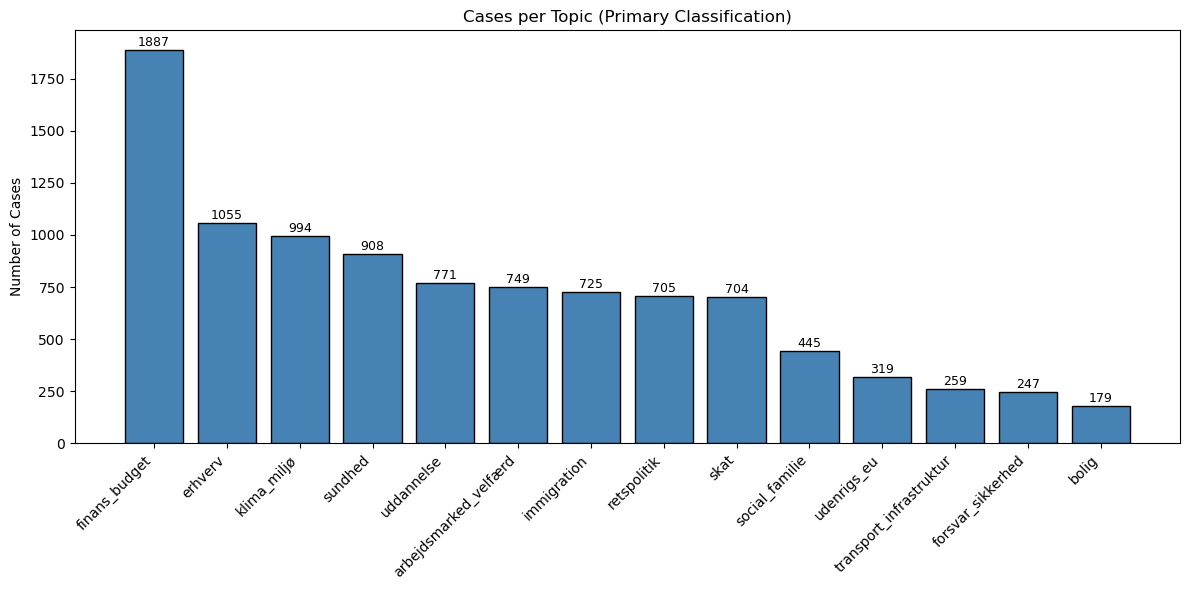

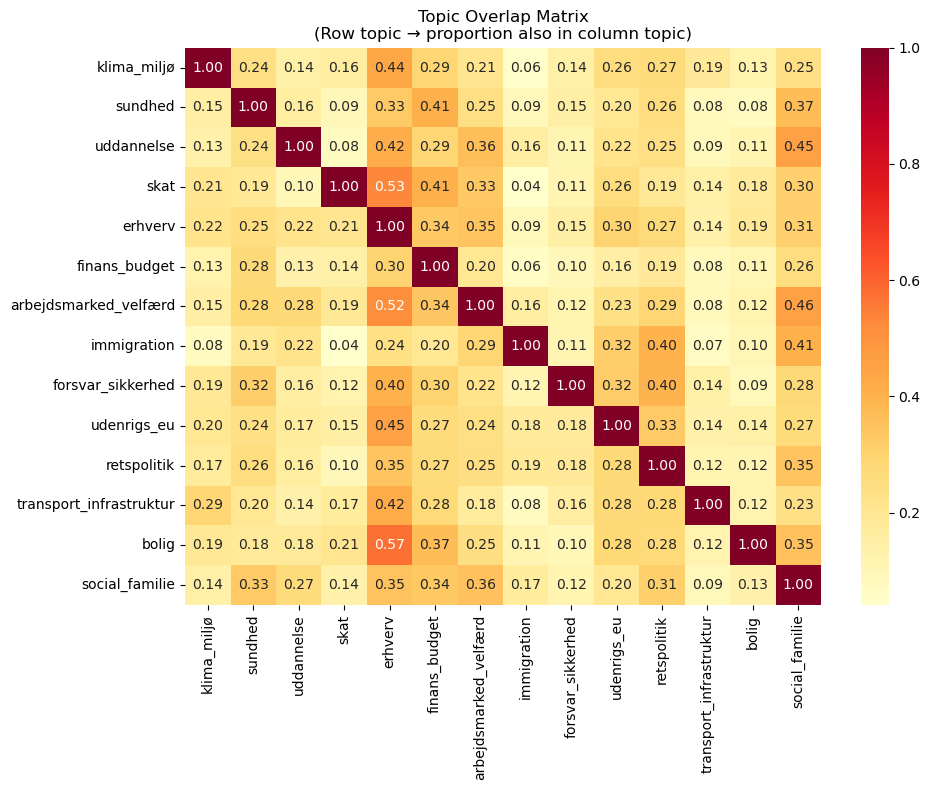

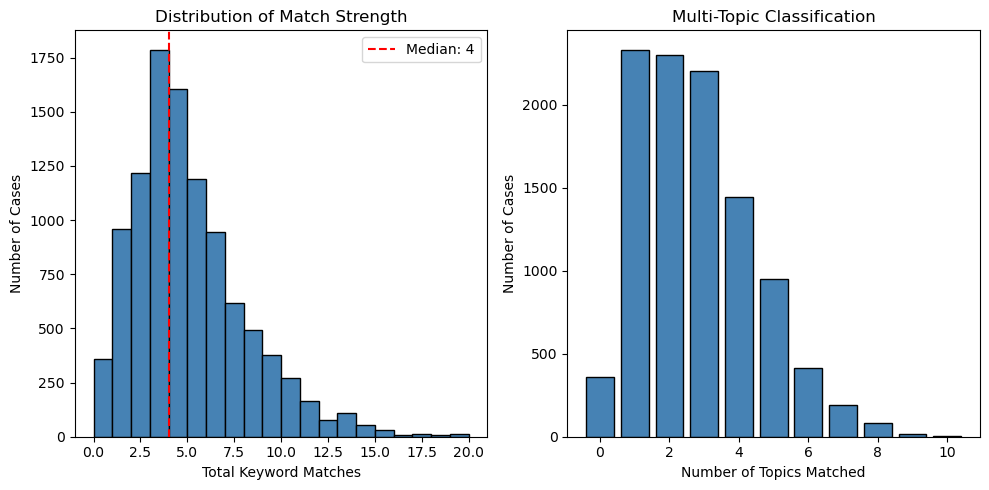

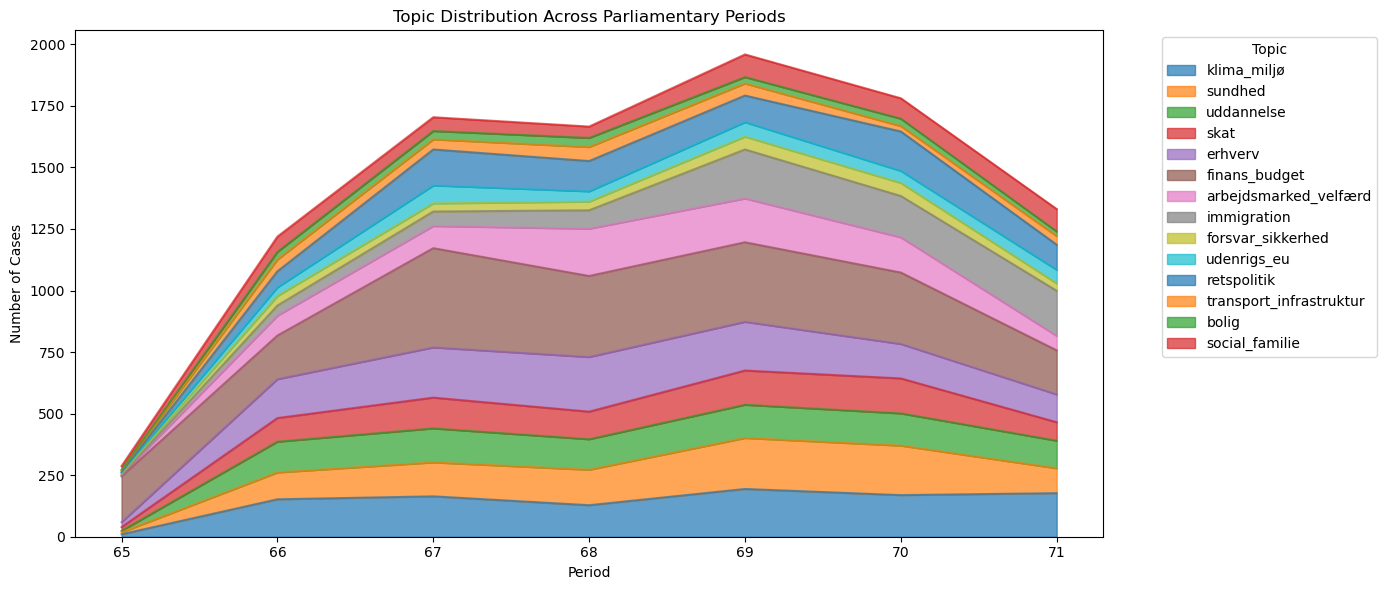

In [44]:
import topic_assigner
import importlib
importlib.reload(topic_assigner)
# Step 1: Stem keywords
print("\nStemming keywords...")
stemmed_keywords = topic_assigner.stem_keyword_dict(keywords)
topics = list(stemmed_keywords.keys())
print(f"      {len(topics)} topics with {sum(len(v) for v in stemmed_keywords.values())} total stemmed keywords")

# Step 2: Classify all cases
print(f"\nClassifying {len(enriched_voting_sessions)} cases...")
classified_df = topic_assigner.classify_all_cases(enriched_voting_sessions, 'topic_texts', stemmed_keywords, threshold=1)
print("      Done!")

# Step 3: Compute statistics
print("\nComputing statistics...")

coverage = topic_assigner.compute_coverage_stats(classified_df)
print(f"\n      COVERAGE STATISTICS:")
print(f"      Total cases:      {coverage['total_cases']}")
print(f"      Classified:       {coverage['classified']} ({coverage['classified_pct']:.1f}%)")
print(f"      Unclassified:     {coverage['unclassified']} ({coverage['unclassified_pct']:.1f}%)")
print(f"      Multi-topic:      {coverage['multi_topic']} ({coverage['multi_topic_pct']:.1f}%)")

topic_stats = topic_assigner.compute_topic_stats(classified_df, topics)
print(f"\n      TOPIC STATISTICS:")
print(topic_stats.to_string(index=False))

overlap = topic_assigner.compute_overlap_matrix(classified_df, topics)
period_dist = None
if 'Period' in enriched_voting_sessions.columns:
    period_dist = topic_assigner.compute_period_distribution(classified_df, 'Period', topics)
    print(f"\n      PERIOD DISTRIBUTION:")
    print(period_dist)

# Step 4: Create visualizations
print("\nCreating visualizations...")

fig1 = topic_assigner.plot_topic_distribution(topic_stats)
fig2 = topic_assigner.plot_overlap_heatmap(overlap)
fig3 = topic_assigner.plot_match_strength_histogram(classified_df)

if period_dist is not None:
    fig4 = topic_assigner.plot_period_distribution(period_dist)

# fig1.savefig('topic_distribution.png', dpi=150, bbox_inches='tight')
# fig2.savefig('topic_overlap.png', dpi=150, bbox_inches='tight')
# fig3.savefig('match_strength.png', dpi=150, bbox_inches='tight')
# if period_dist is not None:
#     fig4.savefig('period_distribution.png', dpi=150, bbox_inches='tight')
# print("      Plots saved!")

In [47]:
from topic_assigner import tokenize_and_stem
import random

# Randomly pick 1 text from each topic and display it with keyword statistics
topics = list(keywords.keys())

for topic in topics:
    # Filter cases where this topic is primary
    topic_cases = classified_df[classified_df['primary_topic'] == topic]
    
    if len(topic_cases) == 0:
        print(f"\n{'='*80}")
        print(f"TOPIC: {topic.upper()}")
        print(f"{'='*80}")
        print("No cases found for this topic")
        continue
    
    # Randomly sample 1 case
    sample_case = topic_cases.sample(n=1, random_state=42).iloc[0]
    
    print(f"\n{'='*80}")
    print(f"TOPIC: {topic.upper()} ({len(topic_cases)} total cases)")
    print(f"{'='*80}")
    print(f"(ID: {sample_case['sag_id']}) {sample_case['sag_titel']}")
    print(f"  Resume: {sample_case['sag_resume'][:100] if pd.notna(sample_case['sag_resume']) else 'N/A'}...")
    
    # Get score for this topic
    score_col = f'score_{topic}'
    score = sample_case[score_col]
    total_matches = sample_case['total_matches']
    
    print(f"  Keyword matches: {score}/{total_matches} total matches")
    
    # Get the actual matched keywords from classify_case
    scores, matched = topic_assigner.classify_case(sample_case['topic_texts'], stemmed_keywords)
    matched_words = matched[topic]
    
    print(f"  Matched keywords: {', '.join(matched_words) if matched_words else 'None'}")
    print(f"  All topics: {sample_case['all_topics']}")



TOPIC: KLIMA_MILJØ (994 total cases)
(ID: 98369.0) Forslag til lov om ændring af lov om kuldioxidafgift af visse energiprodukter, lov om energiafgift af mineralolieprodukter m.v., lov om afgift af naturgas og bygas m.v., lov om afgift af stenkul, brunkul og koks m.v. og forskellige andre love. (Gennemførelse af dele af »Aftale om Grøn skattereform for industri mv.« fra juni 2022, ændringer som følge af emissionsafgiftsloven og udvidelse af adgang til ekstraordinær genoptagelse på afgiftsområdet m.v.).
  Resume: Lovforslaget har til formål at udmønte dele af "Aftale om grøn skattereform for industri m.v." indgå...
  Keyword matches: 5/13 total matches
  Matched keywords: energi(in:energiproduk), natur(in:naturga), emission, grøn, affald
  All topics: ['klima_miljø', 'skat', 'erhverv', 'bolig', 'social_familie']

TOPIC: SUNDHED (908 total cases)
(ID: 97388.0) Forslag til folketingsbeslutning om at ændre forældelsesreglerne i ministeransvarlighedsloven, så det bl.a. sikres, at der ikke i

In [48]:
classified_df.to_csv('./voting-data/voting_sessions_enriched.csv', index=False)
print("\nData saved to '/voting-data/voting_sessions_enriched.csv'")


Data saved to '/voting-data/voting_sessions_enriched.csv'


## Working with individual votes

# Analysis

## Narrowing down
Her skriver og illustrerer vi hvorfor vi har valgt de emner og perioder vi har.

## Graphs

### Centrality

### Backboning

## NLP

### Dispersion/Frequency Distributions

### Wordclouds

## Sum up/connected reflections